In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import fetch_openml
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
 accuracy_score,
 confusion_matrix,
 classification_report,
 roc_auc_score,
 log_loss,
 RocCurveDisplay,
)

In [2]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

X = X / 255.0

X = X[:10000]
y = y[:10000]

In [3]:
models = {
    "liblinear": OneVsRestClassifier(
        LogisticRegression(
            solver="liblinear",
            max_iter=1000
        )
    ),
    "lbfgs": LogisticRegression(
        solver="lbfgs",
        max_iter=1000
    ),
    "saga": LogisticRegression(
        solver="saga",
        max_iter=1000
    )
}

In [4]:
results = {}
for solver_name, model in models.items():
    print(solver_name)

    scores = cross_val_score(
        model,
        X,
        y,
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    )

    results[solver_name] = scores

    print("Cross-validation scores:", scores)
    print("Mean accuracy:", scores.mean())
    print("Standard deviation:", scores.std())
    print()


liblinear
Cross-validation scores: [0.90071986 0.91179118 0.89078908]
Mean accuracy: 0.9011000380181989
Standard deviation: 0.008578284873902666

lbfgs
Cross-validation scores: [0.90461908 0.90909091 0.88868887]
Mean accuracy: 0.900799618054187
Standard deviation: 0.008756026740861926

saga
Cross-validation scores: [0.90431914 0.90879088 0.88958896]
Mean accuracy: 0.9008996580521881
Standard deviation: 0.008203578801474374



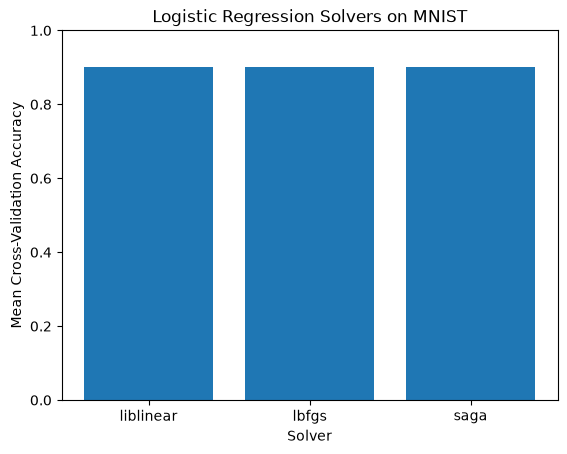

In [5]:
solver_names = list(results.keys())

mean_scores = [
    results[name].mean()
    for name in solver_names
]

plt.bar(
    solver_names,
    mean_scores
)

plt.xlabel("Solver")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("Logistic Regression Solvers on MNIST")

plt.ylim(0, 1)

plt.show()

In [ ]:
print("Final Results:")
for solver in solver_names:
    print(
        f"{solver}: "
        f"{results[solver].mean():.4f} "
        f"std: {results[solver].std():.4f}"
    )

Final Results:
liblinear: 0.9011 std: 0.0086
lbfgs: 0.9008 std: 0.0088
saga: 0.9009 std: 0.0082
